In [59]:
using PyPlot
using JLD2
using Statistics
using MAT
using Images, ImageMorphology

In [60]:
pathdir_stripe_90 = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°
mask_dilation = 17
Ntot = 185491; # Total atom nbr

In [61]:
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" ODs
@load "Saved_exp_data/Intensity_integrated_mask_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" I_atoms_masked_ds I_bkg_masked_ds I_dark_masked_ds Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms;

### Check OD

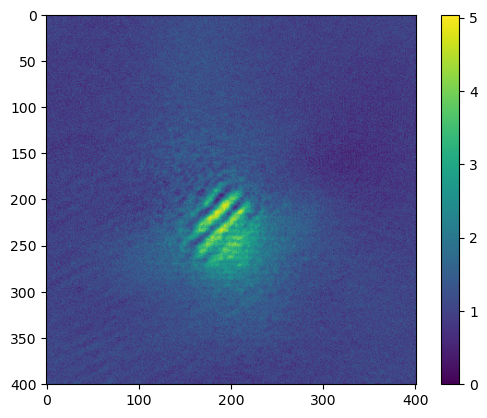

PyObject <matplotlib.colorbar.Colorbar object at 0x1890db1a0>

In [62]:
i, j = 19, 20
OD = ODs[(j-1)*size(I_bkg_masked_ds)[1]+i, :, :]

# idx = 39
# OD = ODs[idx, :, :]

OD = Ntot/sum(OD .- minimum(OD)) .* (OD .- minimum(OD)) # Transform the OD in atom/pxl^2

img = imshow(OD)
colorbar(img)

In [63]:
size(I_atoms_masked_ds)

(19, 20)

In [64]:
Nbr_atoms_per_mask = zeros(size(I_atoms_masked_ds)[1:2])
se = ones(Bool, mask_dilation, mask_dilation)

for i in 1:size(I_atoms_masked_ds)[1]
    for j in 1:size(I_atoms_masked_ds)[2]
        matopen("Saved_masks/$((j-1)*size(I_bkg_masked_ds)[1]+i).mat") do file
            # println("$((j-1)*size(I_bkg_masked_ds)[1]+i)")
            mask, xStart, yStart = read(file, "binaryMask")', read(file, "xStart")', read(file, "yStart")'
            
            OD = ODs[(i-1)*size(I_atoms_masked_ds)[1]+j, :, :]
            OD = OD[Int(xStart):size(mask)[1]+Int(xStart)-1, Int(yStart):size(mask)[2]+Int(yStart)-1] # Crop to match mask size
            OD = Ntot/sum(OD .- minimum(OD)) .* (OD .- minimum(OD)) # Transform the OD in atom/pxl^2

            mask_dilated = dilate(mask, se)
            Nbr_atoms_per_mask[i, j] = sum(OD .* mask_dilated)
        end
    end
end    

In [65]:
@save "Saved_exp_data/Nbr_atoms_per_mask_"*join(split(pathdir_stripe_90, "/")[3:end], "_")*".jld2" Nbr_atoms_per_mask

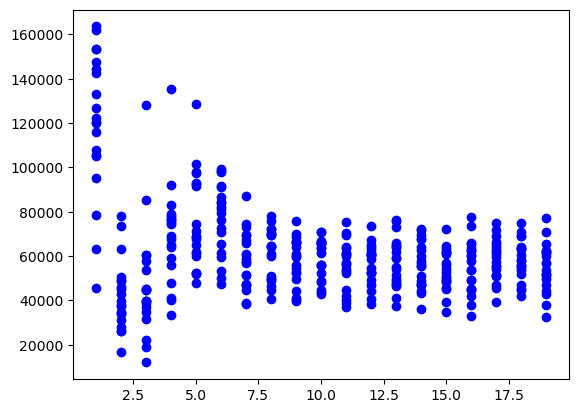

In [66]:
close("all")
fig = subplot()
for i in 1:size(Nbr_atoms_per_mask)[1]
    scatter(i*ones(size(Nbr_atoms_per_mask)[2]), Nbr_atoms_per_mask[i, :], color="b")
end
pygui(false);

### Brouillons

In [67]:
# file = matopen("Saved_masks/75.mat")
#             mask, xStart, yStart = read(file, "binaryMask")', read(file, "xStart")', read(file, "yStart")'

# imshow(ODs[75, Int(xStart):Int(xStart)+size(mask)[1]-1, Int(yStart):Int(yStart)+size(mask)[2]-1] .* mask .+ODs[75, Int(xStart):Int(xStart)+size(mask)[1]-1, Int(yStart):Int(yStart)+size(mask)[2]-1])


# # Compute the simulated intensity for each image
# I_sim = zeros((idx_hb-idx_lb+1, size(I_bkg_masked_ds)[2]))

# for i = idx_lb:idx_hb
#     for j = 1:size(I_bkg_masked_ds)[2]
#             file = matopen("Saved_masks/$((i-1)*size(I_bkg_masked_ds)[2]+j).mat")
#             S_mask = length(read(file, "binaryMask")) * size_pxl^2
            
#             I_sim[i-idx_lb+1, j] += (Nbr_atoms_per_stripe[i, j, k]/(N*length(n_list)*S_stripe)) * interp_linear_sim(factor_sat * Ibkg_stripe_90[i, j]/Isat)
#     end
# end